# Phase 1 — Exploratory Data Analysis
**Author:** Paige Leeseberg  
**Date:** 2026-05-02  
**Purpose:** Understand the PhysioNet 2019 dataset before touching it for modeling.
Load a sample of 500 patients (250 from each set), inspect structure, missingness,
class imbalance, stay lengths, and clinical signal. All findings go to lab_notebook/lab_journal.md.

**Rule:** Never load post-onset rows into EDA intended to inform modeling decisions.

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

np.random.seed(42)

In [23]:
SET_A = "../data/raw/training_setA"
SET_B = "../data/raw/training_setB"
SAMPLE_SIZE = 250  # per set — 500 total

## 1. Load Sample
Load 250 patients from each set. Each file is one patient. We add `patient_id` (from filename)
and `training_set` ('A' or 'B') at load time — these columns must be preserved through every
stage of the pipeline.

In [24]:
def load_sample(folder: str, training_set: str, sample_size: int = 250, seed: int = 42) -> pd.DataFrame:
    """
    Load a random sample of patient PSV files from a training set folder.

    Parameters
    ----------
    folder : str
        Path to the folder containing .psv patient files.
    training_set : str
        Label for this set ('A' or 'B'), added as a column.
    sample_size : int
        Number of patient files to sample.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Combined dataframe with patient_id and training_set columns added.
        One row per patient-hour.
    """
    rng = np.random.default_rng(seed)
    files = glob.glob(os.path.join(folder, "*.psv"))
    print(f"[Set {training_set}] Found {len(files)} files. Sampling {min(sample_size, len(files))}.")

    if sample_size < len(files):
        files = list(rng.choice(files, sample_size, replace=False))

    dfs = []
    for f in tqdm(files, desc=f"Loading set {training_set}"):
        df = pd.read_csv(f, sep="|")
        df["patient_id"] = os.path.basename(f).replace(".psv", "")
        df["training_set"] = training_set
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [25]:
df_a = load_sample(SET_A, training_set="A", sample_size=SAMPLE_SIZE)
df_b = load_sample(SET_B, training_set="B", sample_size=SAMPLE_SIZE)
df = pd.concat([df_a, df_b], ignore_index=True)

print(f"\nCombined shape: {df.shape}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"\nRows per set:")
print(df.groupby('training_set').size().rename('rows'))
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

[Set A] Found 20336 files. Sampling 250.


Loading set A: 100%|██████████| 250/250 [00:00<00:00, 969.51it/s] 


[Set B] Found 20000 files. Sampling 250.


Loading set B: 100%|██████████| 250/250 [00:00<00:00, 1033.63it/s]


Combined shape: (18724, 43)
Unique patients: 500

Rows per set:
training_set
A    9700
B    9024
Name: rows, dtype: int64

Columns (43):
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id', 'training_set']


In [26]:
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,training_set
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,65.78,0,NaN,NaN,-0.01,1,0,p020390,A
1,105.0,98.0,NaN,132.5,85.50,NaN,22.5,NaN,NaN,NaN,...,NaN,65.78,0,NaN,NaN,-0.01,2,0,p020390,A
2,80.0,94.0,NaN,115.0,84.33,NaN,17.0,NaN,NaN,28.0,...,232.0,65.78,0,NaN,NaN,-0.01,3,0,p020390,A
3,101.0,97.5,NaN,113.5,88.83,NaN,17.5,NaN,NaN,NaN,...,NaN,65.78,0,NaN,NaN,-0.01,4,0,p020390,A
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,65.78,0,NaN,NaN,-0.01,5,0,p020390,A


## 2. Class Imbalance
Two different questions:
- **Row-level:** what fraction of all ICU-hours have SepsisLabel=1?
- **Patient-level:** what fraction of patients ever developed sepsis?

These will differ because the SepsisLabel=1 window is only ~6 hours — a small slice of a
patient's total ICU stay. A patient who develops sepsis at hour 54 of a 60-hour stay
contributes 6 positive rows out of 60 total. This dilutes the row-level positive rate
below the patient-level rate, making the imbalance problem even harder for row-by-row models.

In [27]:
row_pct = df['SepsisLabel'].mean() * 100

patient_sepsis = df.groupby('patient_id')['SepsisLabel'].max()
patient_pct = patient_sepsis.mean() * 100
n_sepsis_patients = patient_sepsis.sum()

print(f"Row-level:     {row_pct:.2f}% of rows have SepsisLabel=1")
print(f"Patient-level: {patient_pct:.2f}% of patients ever have SepsisLabel=1")
print(f"\nSepsis patients in sample: {n_sepsis_patients:.0f} of {len(patient_sepsis)}")

Row-level:     1.59% of rows have SepsisLabel=1
Patient-level: 6.20% of patients ever have SepsisLabel=1

Sepsis patients in sample: 31 of 500


## 3. Missingness (Pre-Onset Rows Only)
Post-onset rows (SepsisLabel=1) are excluded before calculating missingness.

**Why:** During and after sepsis onset, clinicians order more tests — labs that were
previously missing start appearing. Including those rows would underestimate how sparse
the data actually is during the pre-onset hours the model will see. Missingness numbers
must reflect the real modeling data, not a rosier picture inflated by intensive-monitoring hours.

This filter is a preview of what `preprocess.py` will do in Phase 2.

In [28]:
def filter_pre_onset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only pre-onset rows for each patient.

    For sepsis patients: keep rows before the first SepsisLabel=1.
    For never-sepsis patients: keep all rows.

    Parameters
    ----------
    df : pd.DataFrame
        Combined dataframe with patient_id and SepsisLabel columns.

    Returns
    -------
    pd.DataFrame
        Filtered dataframe with post-onset rows removed.
    """
    def keep_pre_onset(patient_df):
        if patient_df['SepsisLabel'].max() == 0:
            return patient_df
        first_onset_pos = (patient_df['SepsisLabel'] == 1).values.argmax()
        return patient_df.iloc[:first_onset_pos]

    return df.groupby('patient_id', group_keys=False).apply(keep_pre_onset)

In [29]:
df_pre = filter_pre_onset(df)

print(f"Rows before filter: {len(df):,}")
print(f"Rows after filter:  {len(df_pre):,}")
print(f"Post-onset rows removed: {len(df) - len(df_pre):,}")
print(f"\nAll remaining SepsisLabel values are 0: {(df_pre['SepsisLabel'] == 0).all()}")

Rows before filter: 18,724
Rows after filter:  18,427
Post-onset rows removed: 297

All remaining SepsisLabel values are 0: True


In [30]:
# Exclude pipeline/admin columns — only check clinical features
exclude = ['patient_id', 'training_set', 'SepsisLabel', 'ICULOS', 'HospAdmTime']
feature_cols = [c for c in df_pre.columns if c not in exclude]

missing_pct = df_pre[feature_cols].isna().mean().sort_values(ascending=False) * 100

print(f"Missingness by column (pre-onset rows only, n={len(df_pre):,} rows):")
print(missing_pct.round(1).to_string())
print(f"\nColumns >80% missing: {list(missing_pct[missing_pct > 80].index)}")
print(f"Columns >50% missing: {list(missing_pct[missing_pct > 50].index)}")

Missingness by column (pre-onset rows only, n=18,427 rows):
Bilirubin_direct    99.8
Fibrinogen          99.4
TroponinI           98.9
Bilirubin_total     98.5
Alkalinephos        98.5
AST                 98.5
EtCO2               97.5
Lactate             97.3
PTT                 97.2
SaO2                96.9
Phosphate           95.9
HCO3                95.7
Chloride            95.4
BaseExcess          94.6
PaCO2               94.5
Platelets           94.2
Calcium             94.0
Creatinine          93.9
WBC                 93.7
Magnesium           93.6
pH                  93.3
BUN                 93.0
Hgb                 92.8
Hct                 91.3
FiO2                91.1
Potassium           90.9
Glucose             84.3
Temp                67.5
Unit1               44.7
Unit2               44.7
DBP                 30.5
Resp                15.5
SBP                 15.1
O2Sat               13.3
MAP                 12.8
HR                  10.1
Gender               0.0
Age            

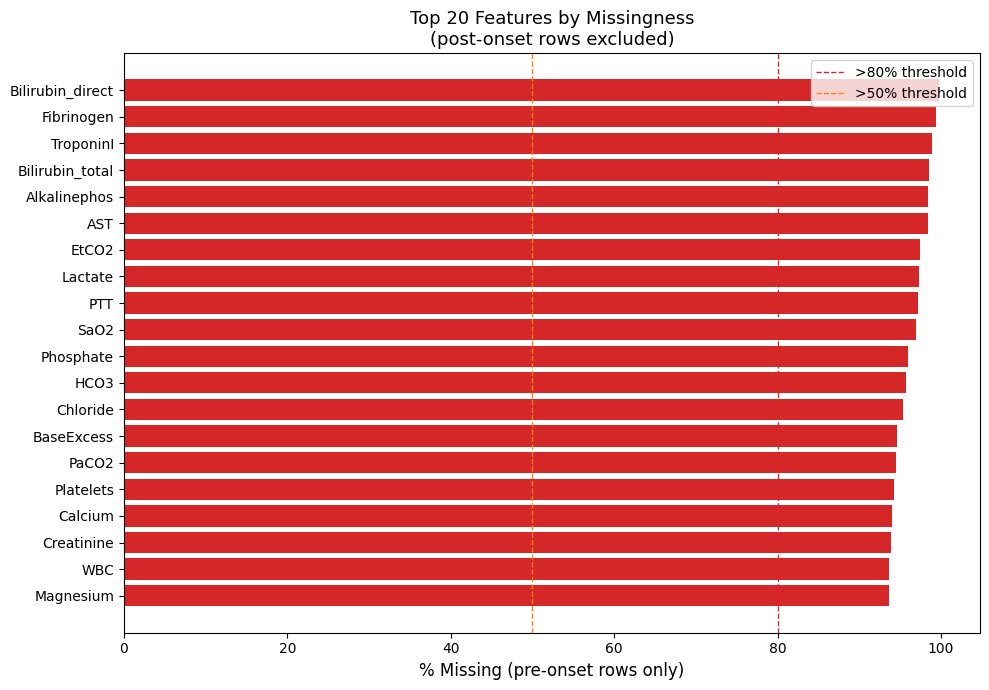

Saved: outputs/figures/missingness_pre_onset.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
top_missing = missing_pct.head(20)
colors = ['#d62728' if v > 80 else '#ff7f0e' if v > 50 else '#1f77b4' for v in top_missing.values]
ax.barh(top_missing.index[::-1], top_missing.values[::-1], color=colors[::-1])
ax.axvline(80, color='#d62728', linestyle='--', linewidth=1, label='>80% threshold')
ax.axvline(50, color='#ff7f0e', linestyle='--', linewidth=1, label='>50% threshold')
ax.set_xlabel('% Missing (pre-onset rows only)', fontsize=12)
ax.set_title('Top 20 Features by Missingness\n(post-onset rows excluded)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/missingness_pre_onset.png', dpi=150)
plt.show()
print('Saved: outputs/figures/missingness_pre_onset.png')

## 4. Missingness as Signal — High-Missingness Labs vs Sepsis Rate

Hypothesis: some labs are ordered precisely because the patient is deteriorating.
If so, patients who ever had the lab drawn should have higher sepsis rates than
patients who never had it drawn.

This uses the **full unfiltered dataset** (`df`) — we need the SepsisLabel=1 rows
present to see whether each lab is associated with sepsis outcome.

Analysis is at the **patient level**: did this patient ever have the lab drawn,
and did they develop sepsis? Avoids double-counting rows from the same patient.

In [32]:
labs_to_check = ['TroponinI', 'Fibrinogen', 'Bilirubin_direct', 'Lactate']

patient_is_sepsis = df.groupby('patient_id')['SepsisLabel'].max().astype(bool)

results = []
for lab in labs_to_check:
    patient_had_lab = df.groupby('patient_id')[lab].apply(lambda x: x.notna().any())

    sepsis_rate_with_lab    = patient_is_sepsis[patient_had_lab].mean() * 100
    sepsis_rate_without_lab = patient_is_sepsis[~patient_had_lab].mean() * 100
    n_with = patient_had_lab.sum()
    n_without = (~patient_had_lab).sum()

    results.append({
        'lab': lab,
        'n_with_lab': n_with,
        'sepsis_rate_with_lab_%': round(sepsis_rate_with_lab, 1),
        'n_without_lab': n_without,
        'sepsis_rate_without_lab_%': round(sepsis_rate_without_lab, 1),
    })

    print(f"{lab}:")
    print(f"  Lab drawn    — {n_with:>3} patients, {sepsis_rate_with_lab:.1f}% sepsis")
    print(f"  Lab missing  — {n_without:>3} patients, {sepsis_rate_without_lab:.1f}% sepsis")
    print()

TroponinI:
  Lab drawn    — 106 patients, 11.3% sepsis
  Lab missing  — 394 patients, 4.8% sepsis

Fibrinogen:
  Lab drawn    —  53 patients, 13.2% sepsis
  Lab missing  — 447 patients, 5.4% sepsis

Bilirubin_direct:
  Lab drawn    —  27 patients, 11.1% sepsis
  Lab missing  — 473 patients, 5.9% sepsis

Lactate:
  Lab drawn    — 147 patients, 12.2% sepsis
  Lab missing  — 353 patients, 3.7% sepsis



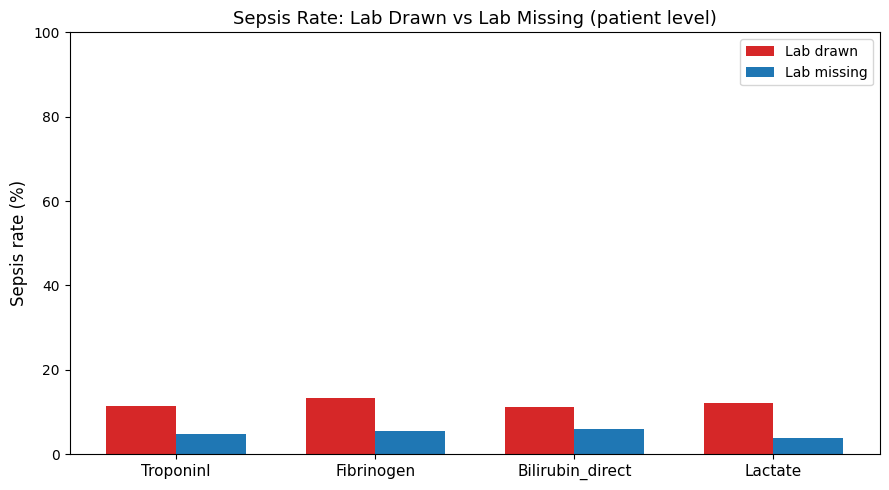

Saved: outputs/figures/lab_drawn_vs_sepsis_rate.png


In [33]:
results_df = pd.DataFrame(results)

x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, results_df['sepsis_rate_with_lab_%'],    width, label='Lab drawn',   color='#d62728')
ax.bar(x + width/2, results_df['sepsis_rate_without_lab_%'], width, label='Lab missing', color='#1f77b4')

ax.set_xticks(x)
ax.set_xticklabels(results_df['lab'], fontsize=11)
ax.set_ylabel('Sepsis rate (%)', fontsize=12)
ax.set_title('Sepsis Rate: Lab Drawn vs Lab Missing (patient level)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../outputs/figures/lab_drawn_vs_sepsis_rate.png', dpi=150)
plt.show()
print('Saved: outputs/figures/lab_drawn_vs_sepsis_rate.png')

### Summary — What the Plot Tells Us

In [ ]:
missingness_lookup = {
    'TroponinI':        98.9,
    'Fibrinogen':       99.4,
    'Bilirubin_direct': 99.8,
    'Lactate':          97.3,
}

summary = results_df.copy()
summary['missingness_%'] = summary['lab'].map(missingness_lookup)
summary['signal_ratio']  = (summary['sepsis_rate_with_lab_%'] / summary['sepsis_rate_without_lab_%']).round(1)
summary['decision']      = 'KEEP — indicator column essential'

summary = summary[[
    'lab', 'missingness_%', 'n_with_lab',
    'sepsis_rate_with_lab_%', 'sepsis_rate_without_lab_%',
    'signal_ratio', 'decision',
]].rename(columns={
    'lab':                       'Lab',
    'missingness_%':             'Missing %',
    'n_with_lab':                'N drawn',
    'sepsis_rate_with_lab_%':    'Sepsis % (drawn)',
    'sepsis_rate_without_lab_%': 'Sepsis % (missing)',
    'signal_ratio':              'Ratio',
    'decision':                  'Decision',
})

print('Lab signal summary (500 patient sample):')
print(summary.to_string(index=False))
print()
print('Ratio = sepsis rate when drawn / sepsis rate when missing.')
print('All four labs show 1.9x–3.3x higher sepsis rate when drawn.')
print()
print('Decision: raise missingness drop threshold from 80% to >99.5%.')
print('Keep all four features. Indicator columns are not optional.')